<a href="https://colab.research.google.com/github/ExcWasHere/PCVK_2026/blob/main/Week5_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# E-1 PERCOBAAN HISTOGRAM

<BarContainer object of 256 artists>

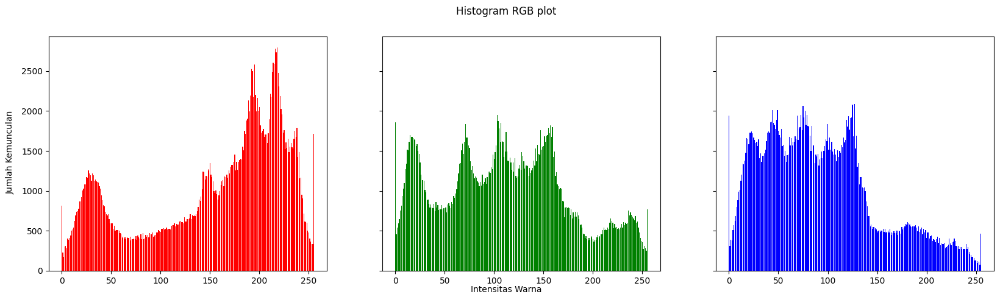

In [3]:
img = cv.imread('/content/drive/MyDrive/Work/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height) :
  for x in range(0, width) :
    red[img[y] [x] [0]] += 1
    green[img[y] [x] [1]] += 1
    blue[img[y] [x] [2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

## Pertanyaan Praktikum E1
#### 1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- Fungsi histogram manual (dari jobsheet) ---
def histogram_manual(channel):
    h = [0] * 256
    for y in range(channel.shape[0]):
        for x in range(channel.shape[1]):
            h[channel[y][x]] += 1
    return np.array(h, dtype=np.int64)

def bandingkan_histogram(path, judul):
    print("=" * 55)
    print(f"HASIL UNTUK: {judul}")
    print(f"Path: {path}")
    print("=" * 55)

    img = cv2.imread(path)
    if img is None:
        print(f"Gambar tidak ditemukan di {path}\n")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Nama kanal sesuai urutan di citra RGB
    kanal_info = [
        ('Merah (R)', 0),
        ('Hijau (G)', 1),
        ('Biru  (B)', 2),
    ]

    for nama, idx in kanal_info:
        ch = img[:, :, idx]

        # Metode 1: Manual (looping)
        h_manual = histogram_manual(ch)

        # Metode 2: numpy.histogram
        h_numpy, _ = np.histogram(ch, bins=256, range=(0, 256))

        # Metode 3: cv.calcHist
        h_cv = cv2.calcHist([ch], [0], None, [256], [0, 256]).flatten()
        h_cv = h_cv.astype(np.int64)

        # Hitung selisih maksimum
        d1 = int(np.max(np.abs(h_manual - h_numpy)))
        d2 = int(np.max(np.abs(h_manual - h_cv)))
        d3 = int(np.max(np.abs(h_numpy  - h_cv)))

        print(f"\nKanal {nama}:")
        print(f"  Max |Manual - NumPy | = {d1}")
        print(f"  Max |Manual - cv2   | = {d2}")
        print(f"  Max |NumPy  - cv2   | = {d3}")
        print(f"  Total piksel  Manual={h_manual.sum()} | "
              f"NumPy={h_numpy.sum()} | cv2={int(h_cv.sum())}")
        print(f"  Status: {'SAMA (selisih 0)' if (d1==0 and d2==0 and d3==0) else 'BEDA'}")

    print()

# TAHAP 1: lena.jpg
bandingkan_histogram(
    '/content/drive/MyDrive/Work/lena.jpg',
    'Lena.jpg (Tahap 1)'
)

# TAHAP 2: KTM1b.jpg
bandingkan_histogram(
    '/content/drive/MyDrive/Work/ktm.jpeg',
    'KTM1b.jpg (Tahap 2)'
)

HASIL UNTUK: Lena.jpg (Tahap 1)
Path: /content/drive/MyDrive/Work/lena.jpg

Kanal Merah (R):
  Max |Manual - NumPy | = 0
  Max |Manual - cv2   | = 0
  Max |NumPy  - cv2   | = 0
  Total piksel  Manual=262144 | NumPy=262144 | cv2=262144
  Status: SAMA (selisih 0)

Kanal Hijau (G):
  Max |Manual - NumPy | = 0
  Max |Manual - cv2   | = 0
  Max |NumPy  - cv2   | = 0
  Total piksel  Manual=262144 | NumPy=262144 | cv2=262144
  Status: SAMA (selisih 0)

Kanal Biru  (B):
  Max |Manual - NumPy | = 0
  Max |Manual - cv2   | = 0
  Max |NumPy  - cv2   | = 0
  Total piksel  Manual=262144 | NumPy=262144 | cv2=262144
  Status: SAMA (selisih 0)

HASIL UNTUK: KTM1b.jpg (Tahap 2)
Path: /content/drive/MyDrive/Work/ktm.jpeg

Kanal Merah (R):
  Max |Manual - NumPy | = 0
  Max |Manual - cv2   | = 0
  Max |NumPy  - cv2   | = 0
  Total piksel  Manual=1656564 | NumPy=1656564 | cv2=1656564
  Status: SAMA (selisih 0)

Kanal Hijau (G):
  Max |Manual - NumPy | = 0
  Max |Manual - cv2   | = 0
  Max |NumPy  - cv2   |

#### 2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi pencahayaan saat akuisisi pada Pertemuan 2.

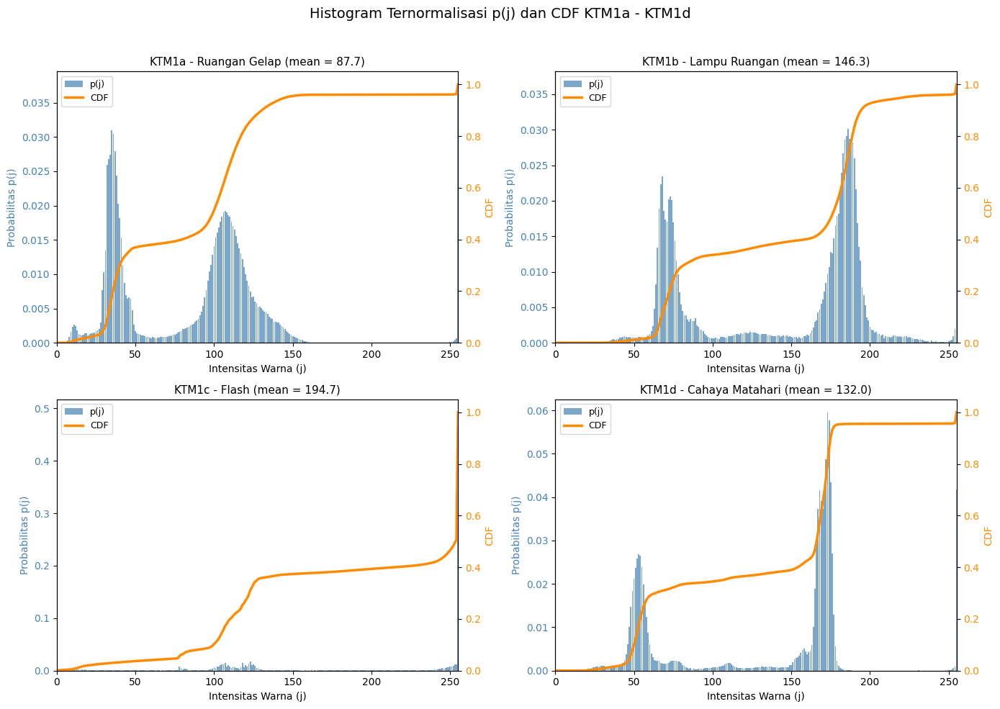

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

daftar_ktm = [
    ('KTM1a.jpg', 'KTM1a - Ruangan Gelap'),
    ('KTM1b.jpg', 'KTM1b - Lampu Ruangan'),
    ('ktm.jpeg', 'KTM1c - Flash'),
    ('KTM1d.jpg', 'KTM1d - Cahaya Matahari'),
]

BASE = '/content/drive/MyDrive/Work/'

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Histogram Ternormalisasi p(j) dan CDF KTM1a - KTM1d', fontsize=14)

for ax, (nama_file, judul) in zip(axs.flat, daftar_ktm):
    img = cv2.imread(BASE + nama_file, cv2.IMREAD_GRAYSCALE)

    if img is None:
        ax.set_title(judul + ' - tidak ditemukan')
        ax.axis('off')
        continue

    h = np.zeros(256, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1

    p = h / img.size
    cdf = np.cumsum(p)

    ax.bar(np.arange(256), p, color='steelblue', alpha=0.7, label='p(j)')
    ax.set_xlabel('Intensitas Warna (j)')
    ax.set_ylabel('Probabilitas p(j)', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax.set_xlim([0, 255])

    ax2 = ax.twinx()
    ax2.plot(np.arange(256), cdf, color='darkorange', linewidth=2.5, label='CDF')
    ax2.set_ylabel('CDF', color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax2.set_ylim([0, 1.05])

    ax.set_title(judul + ' (mean = ' + str(round(img.mean(), 1)) + ')', fontsize=11)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Penjelasan (E1 no. 2)** - lengkapi kalimat dengan angka dari tabel di atas.

- **Citra paling gelap** (KTM1a, foto di ruangan gelap): kurva CDF **naik sangat cepat di sisi kiri** (intensitas rendah) lalu mendatar mendekati 1 jauh sebelum intensitas 255. Artinya hampir seluruh piksel menumpuk di intensitas rendah, sedangkan sisi kanan histogram kosong. Ini terjadi karena cahaya yang masuk ke sensor kamera sangat sedikit sehingga sinyal piksel kecil.
- **Citra paling terang** (mis. KTM1d di luar ruangan / KTM1c dengan flash): kurva CDF **hampir datar di awal** (sedikit piksel gelap), lalu **naik tajam di sisi kanan** (intensitas tinggi). Piksel menumpuk di kanan karena cahaya matahari/flash yang kuat, dan bila ada tumpukan di 255 berarti terjadi *clipping* (overexposure).
- Bentuk CDF yang berbeda ini langsung mencerminkan kondisi pencahayaan saat akuisisi pada Pertemuan 2: makin sedikit cahaya, CDF makin melengkung ke kiri-atas; makin banyak cahaya, CDF makin melengkung ke kanan-bawah. Citra dengan pencahayaan merata (KTM1b, lampu ruangan) berada di antara keduanya dan CDF-nya lebih mendekati garis diagonal.

#### 3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan 256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang ketika jumlah bin dikurangi.

In [6]:
NAMA = 'Excell Christian Wulantoro Sadik'
NIM = '244107020227'

N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

print('NAMA :', NAMA)
print('NIM  :', NIM, '| N =', N)
for k, v in PARAM.items():
    print(k, ':', v)

NAMA : Excell Christian Wulantoro Sadik
NIM  : 244107020227 | N = 227
bins : 64
clip : 2.0
tile : 5
L : 8


# E-2 PERCOBAAN HISTOGRAM EQUALIZATION


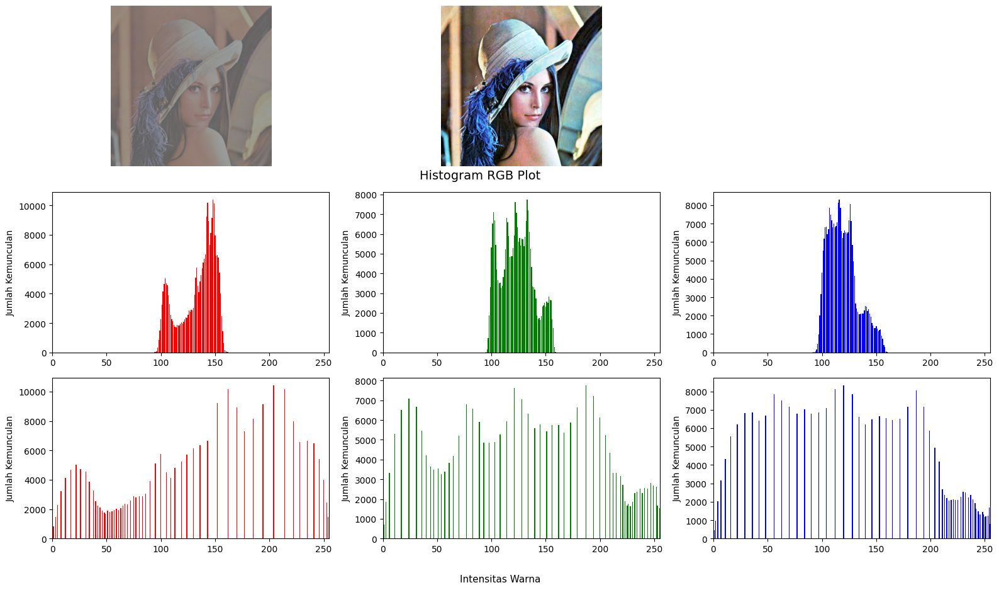

In [7]:
import cv2

def he_manual(channel):
  h = np.zeros(256, dtype=np.int64)
  for i in range(channel.shape[0]):
    for j in range(channel.shape[1]):
      h[channel[i,j]] += 1

  total = channel.size
  p = h/ total
  cdf = np.cumsum(p)
  s = np.round(255 * cdf).astype(np.uint8)
  return s[channel], h

img = cv.imread('/content/drive/MyDrive/Work/lena_lc.jpg')

r_he , h_r_asli = he_manual(img[:,:,2])
g_he , h_g_asli = he_manual(img[:,:,1])
b_he , h_b_asli = he_manual(img[:,:,0])

hasil = np.stack((b_he, g_he, r_he), axis=2)

h_r_hasil = np.zeros(256, dtype=np.int64)
h_g_hasil = np.zeros(256, dtype=np.int64)
h_b_hasil = np.zeros(256, dtype=np.int64)

for i in range(hasil.shape[0]):
  for j in range(hasil.shape[1]):
    h_b_hasil[hasil[i,j,0]] += 1
    h_g_hasil[hasil[i,j,1]] += 1
    h_r_hasil[hasil[i,j,2]] += 1

fig = plt.figure(figsize=(16,10))

ax_img1 = fig.add_subplot(3,3,1)
ax_img1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax_img1.axis('off')

ax_img2 = fig.add_subplot(3,3,2)
ax_img2.imshow(cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB))
ax_img2.axis('off')

ax_img3 = fig.add_subplot(3,3,3)
ax_img3.axis('off')

warna = ['red', 'green', 'blue']
h_asli = [h_r_asli, h_g_asli, h_b_asli]
h_hasil = [h_r_hasil, h_g_hasil, h_b_hasil]

for k in range(3):
  ax_a = fig.add_subplot(3,3,4+k)
  ax_a.bar(np.arange(256), h_asli[k], color=warna[k])
  ax_a.set_xlim([0,255])
  ax_a.set_ylabel('Jumlah Kemunculan')

  ax_b = fig.add_subplot(3,3,7+k)
  ax_b.bar(np.arange(256), h_hasil[k], color=warna[k])
  ax_b.set_xlim([0,255])
  ax_b.set_ylabel('Jumlah Kemunculan')

fig.text(0.42, 0.66, 'Histogram RGB Plot', fontsize=14)
fig.text(0.5, 0.02, 'Intensitas Warna', ha='center', fontsize=11)

plt.tight_layout(rect=[0,0.05,1, 0.95])
plt.show()

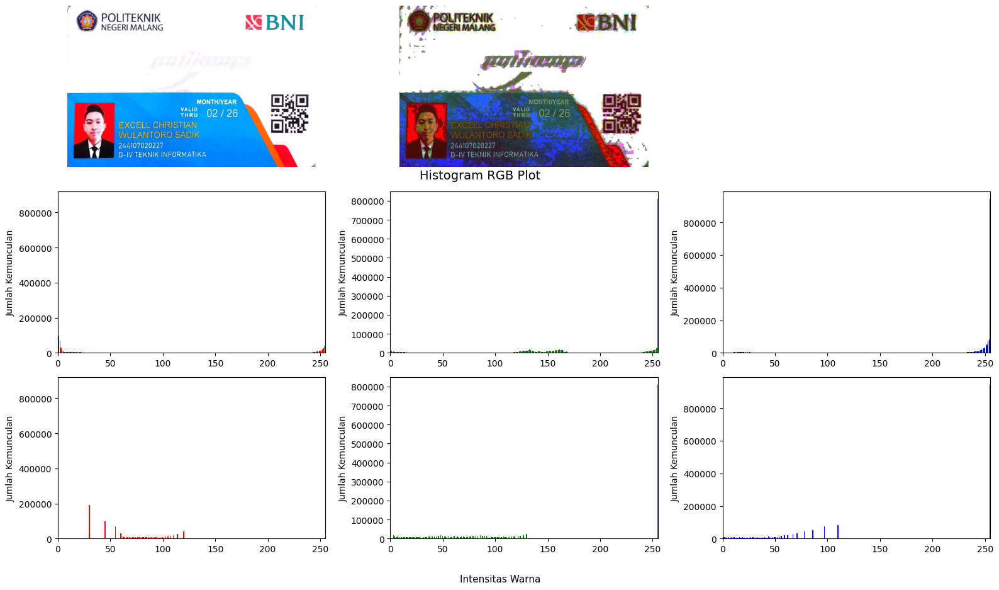

In [8]:

import cv2

def he_manual(channel):
  h = np.zeros(256, dtype=np.int64)
  for i in range(channel.shape[0]):
    for j in range(channel.shape[1]):
      h[channel[i,j]] += 1

  total = channel.size
  p = h/ total
  cdf = np.cumsum(p)
  s = np.round(255 * cdf).astype(np.uint8)
  return s[channel], h

img = cv.imread('/content/drive/MyDrive/Work/ktm.jpeg')

r_he , h_r_asli = he_manual(img[:,:,2])
g_he , h_g_asli = he_manual(img[:,:,1])
b_he , h_b_asli = he_manual(img[:,:,0])

hasil = np.stack((b_he, g_he, r_he), axis=2)

h_r_hasil = np.zeros(256, dtype=np.int64)
h_g_hasil = np.zeros(256, dtype=np.int64)
h_b_hasil = np.zeros(256, dtype=np.int64)

for i in range(hasil.shape[0]):
  for j in range(hasil.shape[1]):
    h_b_hasil[hasil[i,j,0]] += 1
    h_g_hasil[hasil[i,j,1]] += 1
    h_r_hasil[hasil[i,j,2]] += 1

fig = plt.figure(figsize=(16,10))

ax_img1 = fig.add_subplot(3,3,1)
ax_img1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax_img1.axis('off')

ax_img2 = fig.add_subplot(3,3,2)
ax_img2.imshow(cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB))
ax_img2.axis('off')

ax_img3 = fig.add_subplot(3,3,3)
ax_img3.axis('off')

warna = ['red', 'green', 'blue']
h_asli = [h_r_asli, h_g_asli, h_b_asli]
h_hasil = [h_r_hasil, h_g_hasil, h_b_hasil]

for k in range(3):
  ax_a = fig.add_subplot(3,3,4+k)
  ax_a.bar(np.arange(256), h_asli[k], color=warna[k])
  ax_a.set_xlim([0,255])
  ax_a.set_ylabel('Jumlah Kemunculan')

  ax_b = fig.add_subplot(3,3,7+k)
  ax_b.bar(np.arange(256), h_hasil[k], color=warna[k])
  ax_b.set_xlim([0,255])
  ax_b.set_ylabel('Jumlah Kemunculan')

fig.text(0.42, 0.66, 'Histogram RGB Plot', fontsize=14)
fig.text(0.5, 0.02, 'Intensitas Warna', ha='center', fontsize=11)

plt.tight_layout(rect=[0,0.05,1, 0.95])
plt.show()

### 2. Lengkapi potongan kode tersebut. Bandingkan hasil equalizeHist dengan hasil implementasi manual Anda dengan menghitung selisih maksimum antara keduanya, baik pada lena_lc.jpg maupun pada KTM1a.jpg, lalu jelaskan penyebab selisih tersebut apabila tidak nol.

lena_lc.jpg
Selisih max kanal B: 0
Selisih max kanal G: 0
Selisih max kanal R: 0


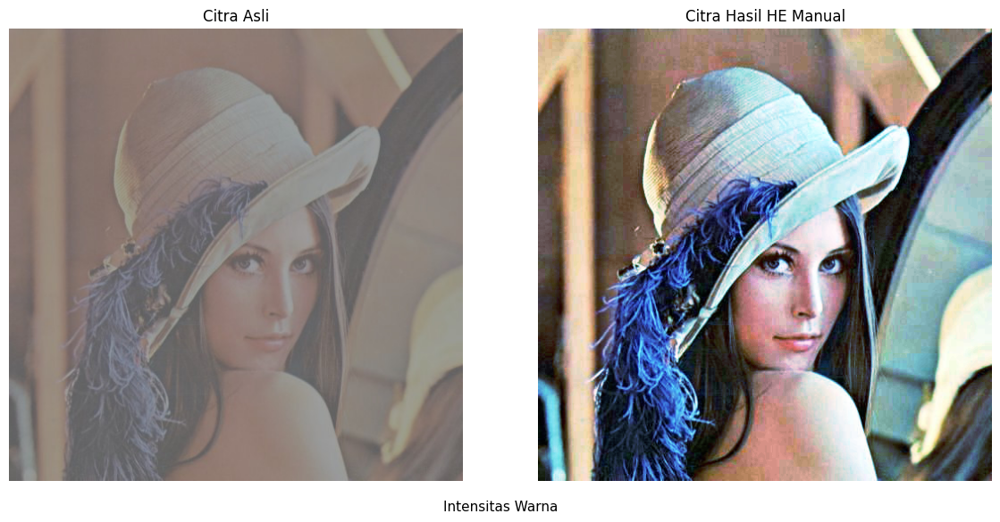

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def he_manual(channel):
    h = np.zeros(256, dtype=np.int64)
    for i in range(channel.shape[0]):
        for j in range(channel.shape[1]):
            h[channel[i,j]] += 1

    total = channel.size
    p = h / total
    cdf = np.cumsum(p)
    s = np.round(255 * cdf).astype(np.uint8)
    return s[channel]

img = cv.imread('/content/drive/MyDrive/Work/lena_lc.jpg')

b, g, r = cv2.split(img)

# Menjalankan fungsi manual
b_manual = he_manual(b)
g_manual = he_manual(g)
r_manual = he_manual(r)

b_eq = cv2.equalizeHist(b)
g_eq = cv2.equalizeHist(g)
r_eq = cv2.equalizeHist(r)

print('lena_lc.jpg')
print('Selisih max kanal B:', np.max(np.abs(b_manual.astype(np.int16) - b_eq.astype(np.int16))))
print('Selisih max kanal G:', np.max(np.abs(g_manual.astype(np.int16) - g_eq.astype(np.int16))))
print('Selisih max kanal R:', np.max(np.abs(r_manual.astype(np.int16) - r_eq.astype(np.int16))))

hasil = np.stack([b_manual, g_manual, r_manual], axis=2)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axs[0].axis('off')
axs[0].set_title('Citra Asli')

axs[1].imshow(cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB))
axs[1].axis('off')
axs[1].set_title('Citra Hasil HE Manual')

fig.text(0.5, 0.02, 'Intensitas Warna', ha='center', fontsize=11)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

lena_lc.jpg
Selisih max kanal B: 1
Selisih max kanal G: 4
Selisih max kanal R: 34


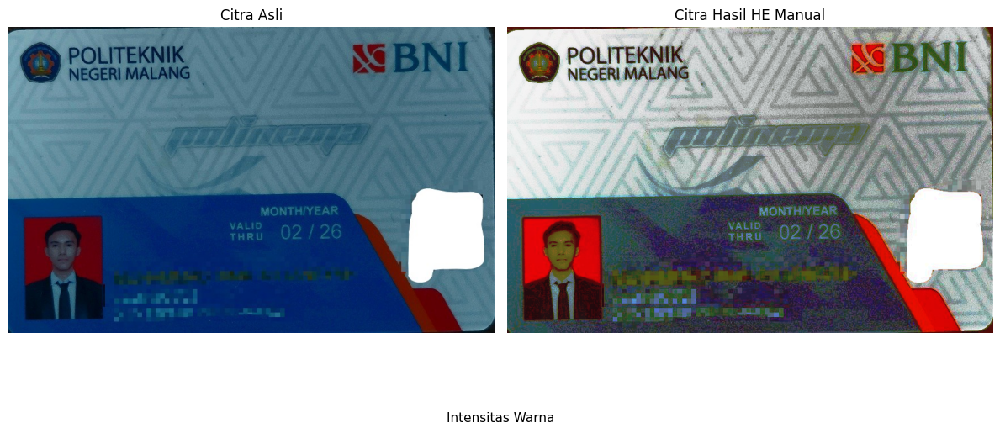

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def he_manual(channel):
    h = np.zeros(256, dtype=np.int64)
    for i in range(channel.shape[0]):
        for j in range(channel.shape[1]):
            h[channel[i,j]] += 1

    total = channel.size
    p = h / total
    cdf = np.cumsum(p)
    s = np.round(255 * cdf).astype(np.uint8)
    return s[channel]

img = cv.imread('/content/drive/MyDrive/Work/KTM1a.jpg')

b, g, r = cv2.split(img)

# Menjalankan fungsi manual
b_manual = he_manual(b)
g_manual = he_manual(g)
r_manual = he_manual(r)

b_eq = cv2.equalizeHist(b)
g_eq = cv2.equalizeHist(g)
r_eq = cv2.equalizeHist(r)

print('lena_lc.jpg')
print('Selisih max kanal B:', np.max(np.abs(b_manual.astype(np.int16) - b_eq.astype(np.int16))))
print('Selisih max kanal G:', np.max(np.abs(g_manual.astype(np.int16) - g_eq.astype(np.int16))))
print('Selisih max kanal R:', np.max(np.abs(r_manual.astype(np.int16) - r_eq.astype(np.int16))))

hasil = np.stack([b_manual, g_manual, r_manual], axis=2)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axs[0].axis('off')
axs[0].set_title('Citra Asli')

axs[1].imshow(cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB))
axs[1].axis('off')
axs[1].set_title('Citra Hasil HE Manual')

fig.text(0.5, 0.02, 'Intensitas Warna', ha='center', fontsize=11)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### 3. Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kali terpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu. Jalankan potongan kode berikut pada citra contoh lena.jpg terlebih dulu, kemudian ulangi pada KTM1d.jpg milik Anda, dan amati warna yang dihasilkan pada keduanya.

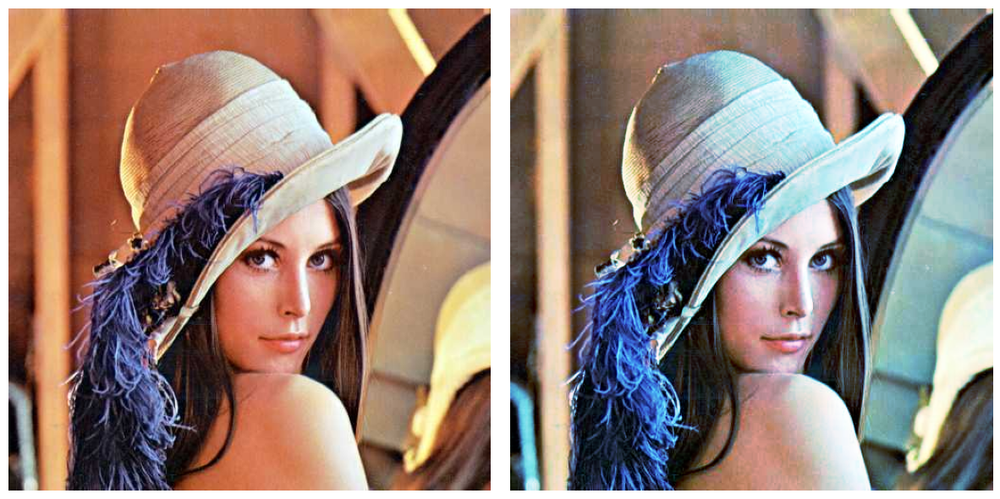

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

berkas = '/content/drive/MyDrive/Work/lena.jpg'

# baca citra berwarna (default BGR dari OpenCV)
bgr = cv.imread(berkas)

# pecah citra jadi 3 kanal: B, G, R
kanal = list(cv.split(bgr))

# loop tiap kanal, terapkan HE per kanal pakai cv.equalizeHist
# hasilnya: tiap kanal punya pemetaan CDF sendiri
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

# gabungkan kembali jadi citra BGR
he_rgb = cv.merge(kanal)

# tampilkan citra asli dan hasil HE per kanal berdampingan
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
axs[1].axis('off')

plt.tight_layout()
plt.show()

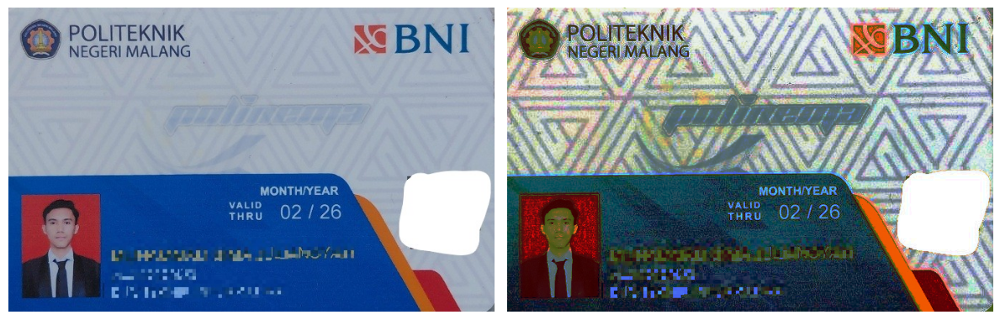

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

berkas = '/content/drive/MyDrive/Work/KTM1d.jpg'

# baca citra berwarna (default BGR dari OpenCV)
bgr = cv.imread(berkas)

# pecah citra jadi 3 kanal: B, G, R
kanal = list(cv.split(bgr))

# loop tiap kanal, terapkan HE per kanal pakai cv.equalizeHist
# hasilnya: tiap kanal punya pemetaan CDF sendiri
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

# gabungkan kembali jadi citra BGR
he_rgb = cv.merge(kanal)

# tampilkan citra asli dan hasil HE per kanal berdampingan
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [13]:
# cara 2: hanya kanal terang yang dikualisasi
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

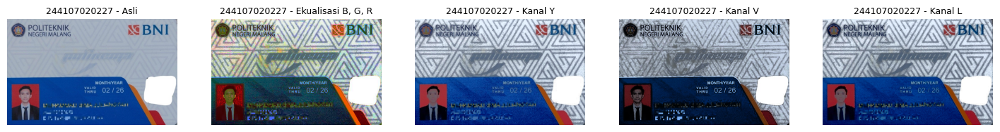

In [14]:

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]
plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

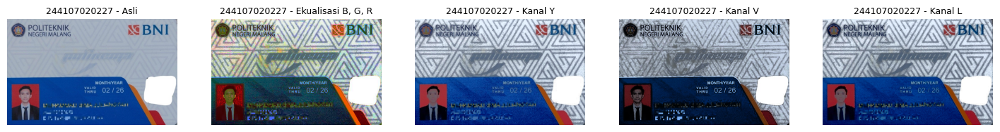

In [15]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

bgr = cv.imread('/content/drive/MyDrive/Work/KTM1d.jpg')

# HE per kanal B, G, R (cara 1)
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# HE kanal Y (YCrCb)
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# HE kanal V (HSV)
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

# HE kanal L (LAB)
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

In [16]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            132.0
Ekualisasi B, G, R                53.38            128.4
Kanal Y                            1.29            132.2
Kanal V                            1.10            110.1
Kanal L                            3.02            124.0


## **E-3 TUGAS PRAKTIKUM DITHERING**

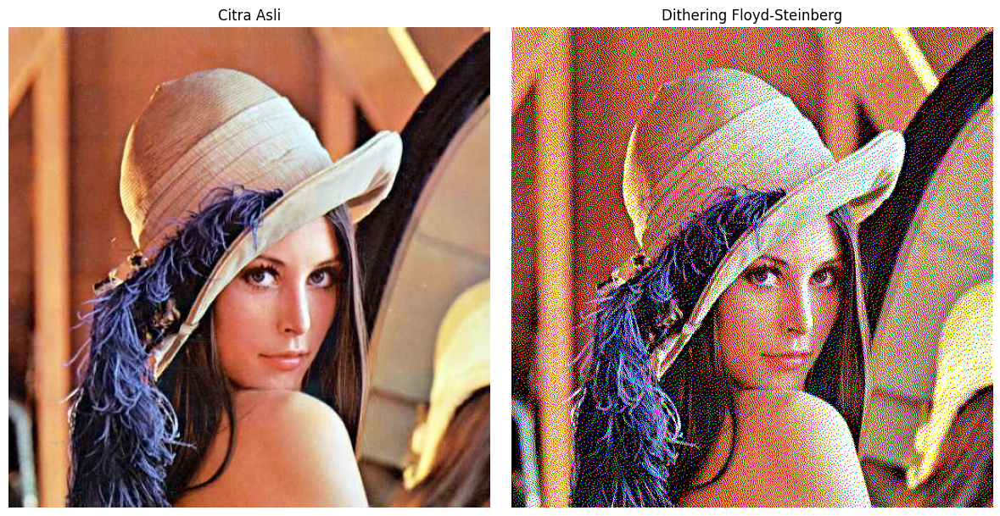

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# fungsi dithering Floyd-Steinberg untuk satu kanal warna
def floyd_steinberg_channel(channel, L=2):
    # ubah ke float32 dulu, supaya penjumlahan error tidak terpotong
    # kalau pakai uint8, nilai yang lebih dari 255 atau kurang dari 0 akan berputar
    img = channel.astype(np.float32).copy()

    # hitung jarak antar level. contoh L=2 -> step = 255/1 = 255
    # L=8 -> step = 255/7 = 36.4
    step = 255.0 / (L - 1)
    H, W = img.shape

    # telusuri citra dari kiri ke kanan, lalu baris atas ke bawah
    for y in range(H):
        for x in range(W):
            # ambil nilai piksel saat ini (sudah termasuk error dari tetangga)
            lama = img[y, x]

            # bulatkan ke level terdekat, ini jadi warna keluaran
            baru = np.round(lama / step) * step
            img[y, x] = baru

            # hitung error = selisih nilai asli dengan nilai keluaran
            error = lama - baru

            # sebar error ke 4 tetangga yang belum diproses
            # sesuai bobot kernel Floyd-Steinberg
            if x + 1 < W:
                img[y, x+1] += error * 7 / 16      # kanan
            if x > 0 and y + 1 < H:
                img[y+1, x-1] += error * 3 / 16    # bawah kiri
            if y + 1 < H:
                img[y+1, x] += error * 5 / 16      # bawah
            if x + 1 < W and y + 1 < H:
                img[y+1, x+1] += error * 1 / 16    # bawah kanan

    # jaga nilai tetap di 0-255 lalu kembalikan ke uint8
    return np.clip(img, 0, 255).astype(np.uint8)


# baca citra lena.jpg berwarna (tanpa IMREAD_GRAYSCALE)
img = cv2.imread('/content/drive/MyDrive/Work/lena.jpg')

# pisahkan jadi 3 kanal: B, G, R
b, g, r = cv2.split(img)

# dithering tiap kanal dengan L=2 (hitam-putih) sesuai tahap 1 modul
b_d = floyd_steinberg_channel(b, L=2)
g_d = floyd_steinberg_channel(g, L=2)
r_d = floyd_steinberg_channel(r, L=2)

# gabungkan kembali jadi citra BGR berwarna
hasil = cv2.merge([b_d, g_d, r_d])

# tampilkan citra asli dan hasil dithering berdampingan
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axs[0].set_title('Citra Asli')
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB))
axs[1].set_title('Dithering Floyd-Steinberg')
axs[1].axis('off')

plt.tight_layout()
plt.show()

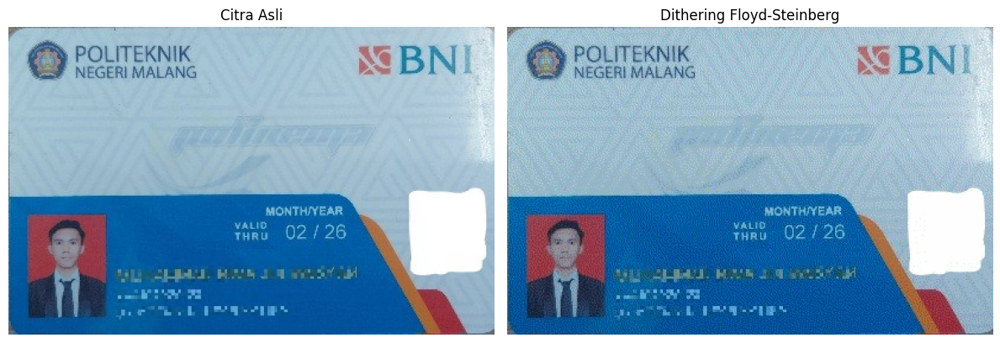

In [18]:
img = cv2.imread('/content/drive/MyDrive/Work/KTM1b.jpg')

b, g, r = cv2.split(img)


b_d = floyd_steinberg_channel(b, L=PARAM['L'])
g_d = floyd_steinberg_channel(g, L=PARAM['L'])
r_d = floyd_steinberg_channel(r, L=PARAM['L'])

hasil = cv2.merge([b_d, g_d, r_d])

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axs[0].set_title('Citra Asli')
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB))
axs[1].set_title('Dithering Floyd-Steinberg')
axs[1].axis('off')

plt.tight_layout()
plt.show()

### 2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang menghasilkan teks pada KTM lebih terbaca.

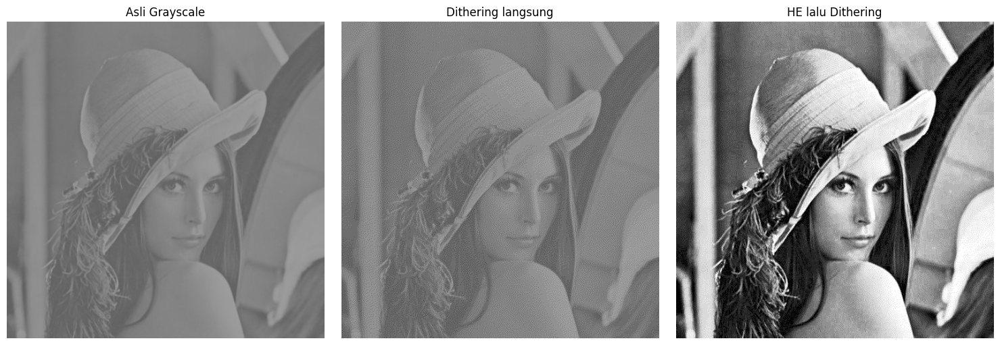

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def he_manual(gray):
    h = np.zeros(256, dtype=np.int64)
    for i in range(gray.shape[0]):
        for j in range(gray.shape[1]):
            h[gray[i, j]] += 1

    total = gray.size
    p = h / total
    cdf = np.cumsum(p)
    s = np.round(255 * cdf).astype(np.uint8)
    return s[gray]


def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            if x + 1 < W:
                img[y, x+1] += error * 7 / 16
            if x > 0 and y + 1 < H:
                img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:
                img[y+1, x] += error * 5 / 16
            if x + 1 < W and y + 1 < H:
                img[y+1, x+1] += error * 1 / 16

    return np.clip(img, 0, 255).astype(np.uint8)

gray = cv2.imread('/content/drive/MyDrive/Work/lena_lc.jpg', cv2.IMREAD_GRAYSCALE)

gray_he = he_manual(gray)
hasil_he_dither = floyd_steinberg(gray_he, L=PARAM['L'])

hasil_dither = floyd_steinberg(gray, L=PARAM['L'])

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(gray, cmap='gray', vmin=0, vmax=255)
axs[0].set_title('Asli Grayscale')
axs[0].axis('off')

axs[1].imshow(hasil_dither, cmap='gray', vmin=0, vmax=255)
axs[1].set_title('Dithering langsung')
axs[1].axis('off')

axs[2].imshow(hasil_he_dither, cmap='gray', vmin=0, vmax=255)
axs[2].set_title('HE lalu Dithering')
axs[2].axis('off')

plt.tight_layout()
plt.show()

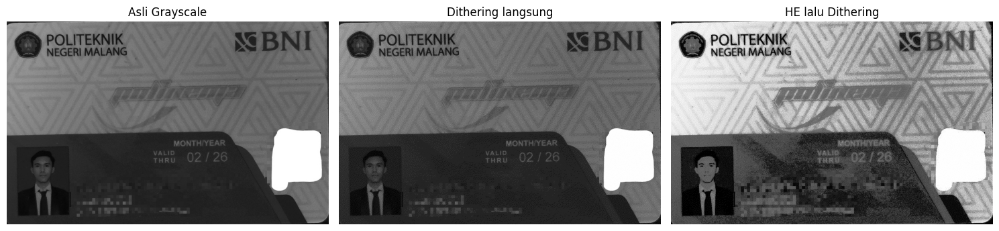

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def he_manual(gray):
    h = np.zeros(256, dtype=np.int64)
    for i in range(gray.shape[0]):
        for j in range(gray.shape[1]):
            h[gray[i, j]] += 1

    total = gray.size
    p = h / total
    cdf = np.cumsum(p)
    s = np.round(255 * cdf).astype(np.uint8)
    return s[gray]


def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            if x + 1 < W:
                img[y, x+1] += error * 7 / 16
            if x > 0 and y + 1 < H:
                img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:
                img[y+1, x] += error * 5 / 16
            if x + 1 < W and y + 1 < H:
                img[y+1, x+1] += error * 1 / 16

    return np.clip(img, 0, 255).astype(np.uint8)

gray = cv2.imread('/content/drive/MyDrive/Work/KTM1a.jpg', cv2.IMREAD_GRAYSCALE)

gray_he = he_manual(gray)
hasil_he_dither = floyd_steinberg(gray_he, L=PARAM['L'])

hasil_dither = floyd_steinberg(gray, L=PARAM['L'])

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(gray, cmap='gray', vmin=0, vmax=255)
axs[0].set_title('Asli Grayscale')
axs[0].axis('off')

axs[1].imshow(hasil_dither, cmap='gray', vmin=0, vmax=255)
axs[1].set_title('Dithering langsung')
axs[1].axis('off')

axs[2].imshow(hasil_he_dither, cmap='gray', vmin=0, vmax=255)
axs[2].set_title('HE lalu Dithering')
axs[2].axis('off')

plt.tight_layout()
plt.show()

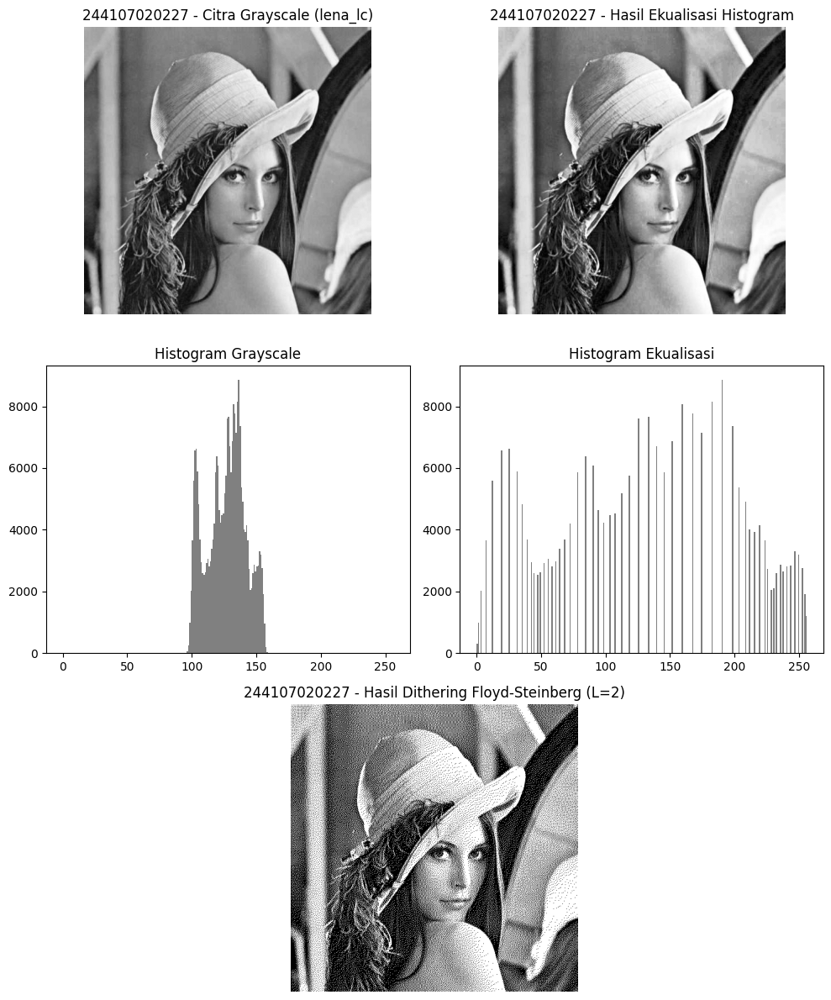

In [21]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

NIM = '244107020227'

def floyd_steinberg_dithering(gray, L=2):
    img = gray.copy().astype(np.float32)
    step = 255.0 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            if x + 1 < W:
                img[y, x + 1] += error * (7 / 16)
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * (3 / 16)
            if y + 1 < H:
                img[y + 1, x] += error * (5 / 16)
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * (1 / 16)

    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

# Membaca citra lena_lc langsung dengan path lengkap
path_lena = '/content/drive/MyDrive/Work/lena_lc.jpg'
img_lena_gray = cv.imread(path_lena, cv.IMREAD_GRAYSCALE)

img_lena_eq = cv.equalizeHist(img_lena_gray)                 # HE dulu untuk menaikkan kontras
img_lena_dither = floyd_steinberg_dithering(img_lena_eq, L=2) # Dithering hasil HE (L=2, hitam-putih)

plt.figure(figsize=(10, 12))

plt.subplot(3, 2, 1)
plt.imshow(img_lena_gray, cmap='gray')
plt.title(NIM + ' - Citra Grayscale (lena_lc)')
plt.axis('off')

plt.subplot(3, 2, 2)
plt.imshow(img_lena_eq, cmap='gray')
plt.title(NIM + ' - Hasil Ekualisasi Histogram')
plt.axis('off')

plt.subplot(3, 2, 3)
plt.hist(img_lena_gray.ravel(), 256, range=[0, 256], color='gray')
plt.title('Histogram Grayscale')

plt.subplot(3, 2, 4)
plt.hist(img_lena_eq.ravel(), 256, range=[0, 256], color='gray')
plt.title('Histogram Ekualisasi')

plt.subplot(3, 1, 3)
plt.imshow(img_lena_dither, cmap='gray')
plt.title(NIM + ' - Hasil Dithering Floyd-Steinberg (L=2)')
plt.axis('off')

plt.tight_layout()
plt.show()

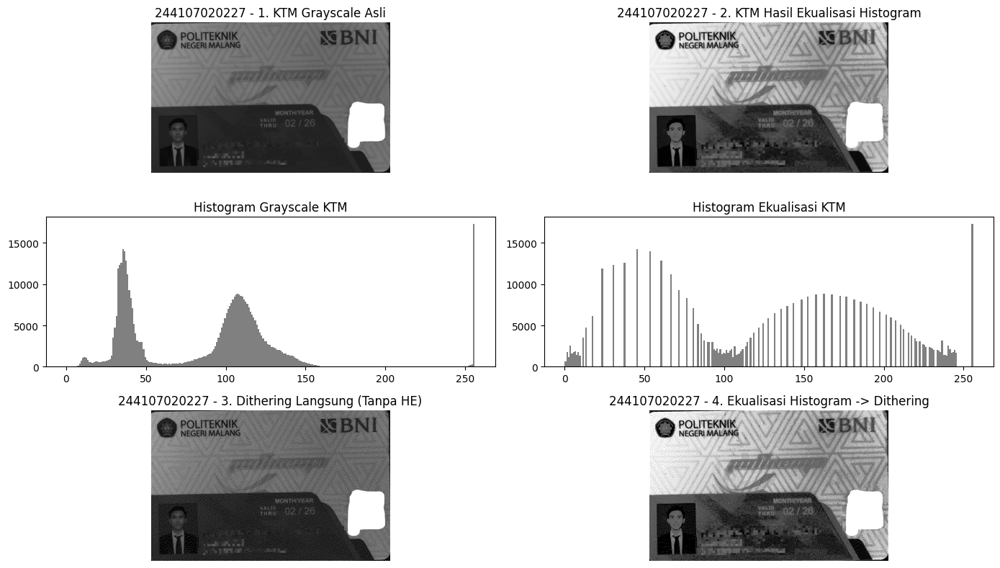

In [22]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

NIM = '244107020227'

def floyd_steinberg_dithering(gray, L=2):
    img = gray.copy().astype(np.float32)
    step = 255.0 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            if x + 1 < W:
                img[y, x + 1] += error * (7 / 16)
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * (3 / 16)
            if y + 1 < H:
                img[y + 1, x] += error * (5 / 16)
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * (1 / 16)

    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

# Membaca citra KTM1a langsung dengan path lengkap
path_ktm = '/content/drive/MyDrive/Work/KTM1a.jpg'
img_ktm_gray = cv.imread(path_ktm, cv.IMREAD_GRAYSCALE)

ktm_dither_direct = floyd_steinberg_dithering(img_ktm_gray, L=2) # Dithering langsung tanpa HE
img_ktm_eq = cv.equalizeHist(img_ktm_gray)
ktm_dither_eq = floyd_steinberg_dithering(img_ktm_eq, L=2)       # HE dulu, baru dithering

plt.figure(figsize=(14, 8))

plt.subplot(3, 2, 1)
plt.imshow(img_ktm_gray, cmap='gray')
plt.title(NIM + ' - 1. KTM Grayscale Asli')
plt.axis('off')

plt.subplot(3, 2, 2)
plt.imshow(img_ktm_eq, cmap='gray')
plt.title(NIM + ' - 2. KTM Hasil Ekualisasi Histogram')
plt.axis('off')

plt.subplot(3, 2, 3)
plt.hist(img_ktm_gray.ravel(), 256, range=[0, 256], color='gray')
plt.title('Histogram Grayscale KTM')

plt.subplot(3, 2, 4)
plt.hist(img_ktm_eq.ravel(), 256, range=[0, 256], color='gray')
plt.title('Histogram Ekualisasi KTM')

plt.subplot(3, 2, 5)
plt.imshow(ktm_dither_direct, cmap='gray')
plt.title(NIM + ' - 3. Dithering Langsung (Tanpa HE)')
plt.axis('off')

plt.subplot(3, 2, 6)
plt.imshow(ktm_dither_eq, cmap='gray')
plt.title(NIM + ' - 4. Ekualisasi Histogram -> Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()